### Importing the libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Loading the dataset

In [6]:
data = pd.read_csv(r'../data/raw_data/diabetes_012_health_indicators_BRFSS2015.csv')

pd.set_option('display.max_columns', None)

data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


| Column                   | Meaning                                                                               |
| ------------------------ | ------------------------------------------------------------------------------------- |
| **Diabetes_012**         | Diabetes status (0 = No diabetes, 1 = Prediabetes, 2 = Diabetes). *(Target variable)* |
| **HighBP**               | 0 = no high BP, 1 = high BP pressure.                                           |
| **HighChol**             | 0 = no high cholesterol, 1 = high cholesterol cholesterol.                                              |
| **CholCheck**            | 0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years years.                                      |
| **BMI**                  | Body Mass Index (weight relative to height).                                          |
| **Smoker**               | Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no, 1 = yes                                 |
| **Stroke**               | (Ever told) you had a stroke. 0 = no, 1 = yes                                                                |
| **HeartDiseaseorAttack** | Coronary Heart Disease (CHD) or Myocardial Infarction (MI) 0 = no, 1 = yes                                         |
| **PhysActivity**         | Physical activity in past 30 days - not including job 0 = no, 1 = yes                                      |
| **Fruits**               | Consume Fruit 1 or more per day 0 = no, 1 = yes                                                 |
| **Veggies**              | Consume Vegetables 1 or more per day 0 = no, 1 = yes                                            |
| **HvyAlcoholConsump**    | Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week) 0 = no, 1 = yes                                                          |
| **AnyHealthcare**        | Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no, 1 = yes                              |
| **NoDocbcCost**          | Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no, 1 = yes                                               |
| **GenHlth**              | Would you say that in general your health is: scale 1-5: 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor                                        |
| **MentHlth**             | Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? It is in days, scale will be between 0-30                           |
| **PhysHlth**             | Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? It is in days, scale will be between 0-30                         |
| **DiffWalk**             | Do you have serious difficulty walking or climbing stairs? 0 = no, 1 = yes                                    |
| **Sex**                  | 0 = female, 1 = male                                                |
| **Age**                  | 13-level age category (_AGEG5YR see codebook21 linked above): scale 1-13: 1 = 18-24, 8 = 55-59, 13 = 80 or older                                  |
| **Education**            | Education level (EDUCA see codebook21 linked above): scale 1-6: 1 = Never attended school or only kindergarten 2 = Grades 1 through 8                               |
| **Income**               | Income scale (INCOME3 see codebook21 linked above): scale 1-8: 1 = less than $10,000 5 = less than $35,000 11 = $200,000 or more                                           |


### EDA

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [4]:
data.shape

(253680, 22)

In [5]:
data.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [6]:
data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
data.select_dtypes(include = 'object').sum()

Series([], dtype: float64)

In [8]:
data.dtypes

Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

In [9]:
data.duplicated().sum()

np.int64(23899)

In [10]:
data[data.duplicated()]

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,2.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,2.0,1.0,1.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,6.0
253550,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,8.0
253563,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
253597,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0


In [11]:
data['Diabetes_012'].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [12]:
data['Diabetes_012'].value_counts().index

Index([0.0, 2.0, 1.0], dtype='float64', name='Diabetes_012')

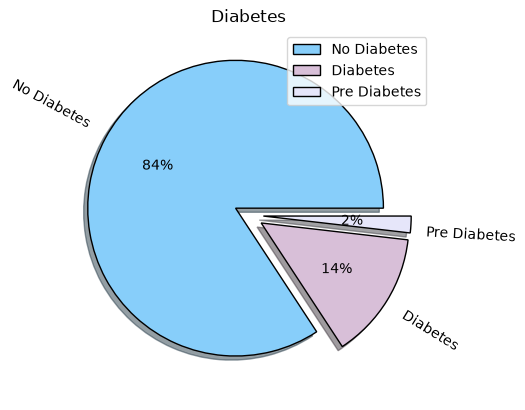

In [13]:
colors = ['lightskyblue', 'thistle', 'lavender']
explode = [0.1, 0.1, 0.1]
labels = ['No Diabetes', 'Diabetes', 'Pre Diabetes']
count_data = data['Diabetes_012'].value_counts()

plt.pie(x = count_data, labels = labels, explode = explode, colors = colors, shadow= True, autopct = '%1.0f%%', rotatelabels = True, wedgeprops = {'edgecolor':'black'})

plt.title('Diabetes')
plt.legend()
plt.show()

# We have imbalance data


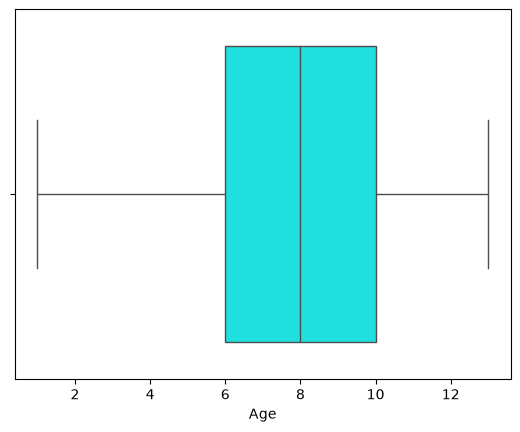

In [14]:
sns.boxplot(x = data['Age'], fill = True, color = 'aqua')
plt.show()
# there is no outlier

In [15]:
data['Age'].value_counts()

Age
9.0     33244
10.0    32194
8.0     30832
7.0     26314
11.0    23533
6.0     19819
13.0    17363
5.0     16157
12.0    15980
4.0     13823
3.0     11123
2.0      7598
1.0      5700
Name: count, dtype: int64

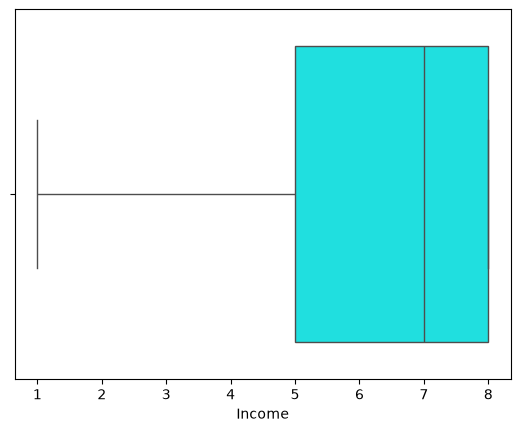

In [16]:
sns.boxplot(x = data['Income'], fill = True, color = 'aqua')
plt.show()
# there is no outlier

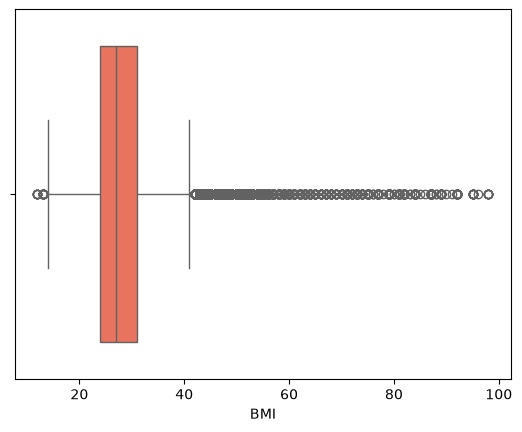

In [17]:
# plt.boxplot(x = data['BMI'], orientation = 'horizontal')
# plt.show()

sns.boxplot(x = data['BMI'], fill = True, color = 'tomato')
plt.show()

# We have outlier

In [18]:
data.query('BMI > 40')

# outlier(11479)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
85,2.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,2.0,30.0,1.0,0.0,9.0,6.0,8.0
97,0.0,1.0,0.0,1.0,45.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,9.0,4.0,6.0
156,2.0,1.0,1.0,1.0,47.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,6.0,5.0
188,0.0,1.0,0.0,1.0,43.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,7.0,1.0,0.0,10.0,5.0,2.0
201,2.0,1.0,1.0,1.0,55.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,4.0,0.0,15.0,0.0,0.0,11.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253547,0.0,1.0,1.0,1.0,44.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,4.0,14.0,30.0,0.0,0.0,3.0,6.0,1.0
253557,0.0,1.0,1.0,1.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,10.0,20.0,1.0,0.0,6.0,4.0,1.0
253567,0.0,1.0,1.0,1.0,44.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,3.0,0.0,0.0,1.0,1.0,11.0,2.0,1.0
253673,0.0,1.0,0.0,1.0,42.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,14.0,4.0,0.0,1.0,3.0,6.0,8.0


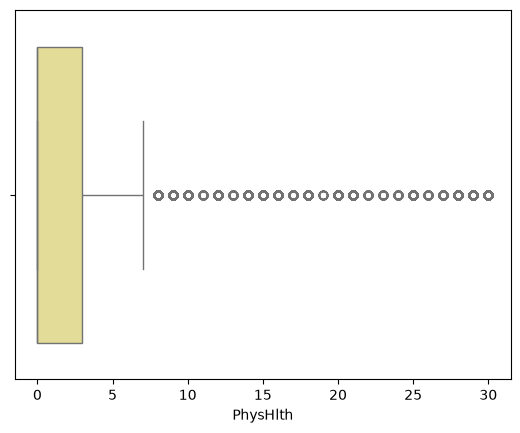

In [19]:
sns.boxplot(x = data['PhysHlth'], fill = True, color = 'khaki')
plt.show()

# we have outlier

In [20]:
data.query('PhysHlth > 7')

# outlier(40949)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
11,0.0,1.0,1.0,1.0,34.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,30.0,1.0,0.0,10.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253652,2.0,0.0,1.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,0.0,30.0,0.0,1.0,11.0,2.0,3.0
253653,0.0,0.0,0.0,1.0,33.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,4.0,0.0,15.0,0.0,1.0,10.0,6.0,3.0
253663,0.0,0.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,2.0,0.0,30.0,0.0,0.0,5.0,6.0,2.0
253665,0.0,0.0,1.0,1.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,30.0,30.0,0.0,0.0,5.0,4.0,1.0


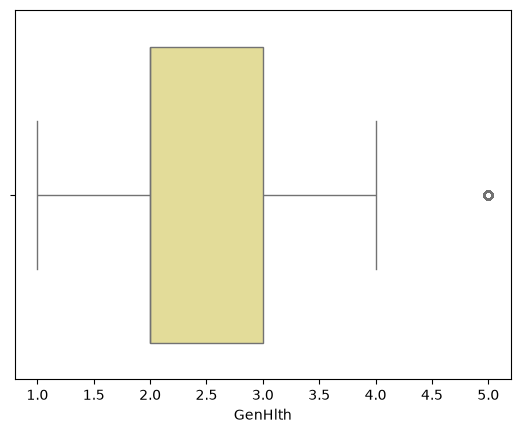

In [21]:
sns.boxplot(x = data['GenHlth'], fill = True, color = 'khaki')
plt.show()

In [22]:
data.query('GenHlth == 5')

# outlier(12081)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
21,0.0,1.0,1.0,1.0,38.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,15.0,30.0,1.0,0.0,13.0,2.0,3.0
26,2.0,1.0,1.0,1.0,37.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.0,0.0,1.0,1.0,10.0,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253601,0.0,1.0,1.0,1.0,19.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0,15.0,20.0,1.0,1.0,12.0,4.0,3.0
253609,0.0,1.0,0.0,1.0,35.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.0,15.0,1.0,0.0,8.0,3.0,4.0
253612,2.0,1.0,1.0,1.0,30.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,5.0,6.0,30.0,1.0,0.0,11.0,2.0,2.0
253626,0.0,0.0,0.0,1.0,29.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,5.0,10.0,30.0,1.0,0.0,5.0,5.0,2.0


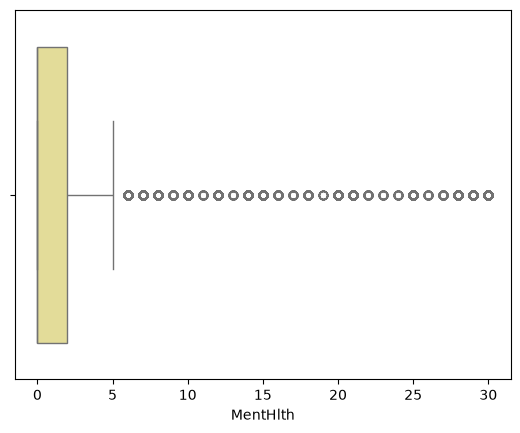

In [23]:
sns.boxplot(x = data['MentHlth'], fill = True, color = 'khaki')
plt.show()

# we have outlier

In [24]:
data.query('MentHlth > 5')

# outlier(36208)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
14,0.0,0.0,1.0,1.0,33.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,4.0,30.0,28.0,0.0,0.0,4.0,6.0,2.0
18,0.0,0.0,0.0,0.0,23.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,15.0,0.0,0.0,0.0,2.0,6.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253648,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,3.0,6.0,14.0,0.0,1.0,5.0,5.0,1.0
253649,0.0,0.0,1.0,1.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,30.0,5.0,0.0,0.0,4.0,6.0,5.0
253665,0.0,0.0,1.0,1.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,30.0,30.0,0.0,0.0,5.0,4.0,1.0
253670,2.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0


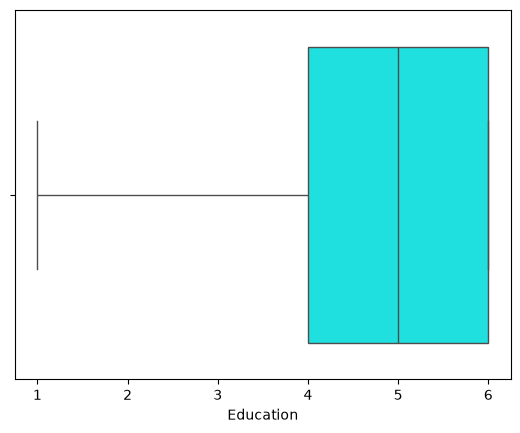

In [25]:
sns.boxplot(x = data['Education'], fill = True, color = 'aqua')
plt.show()
# there is no outlier

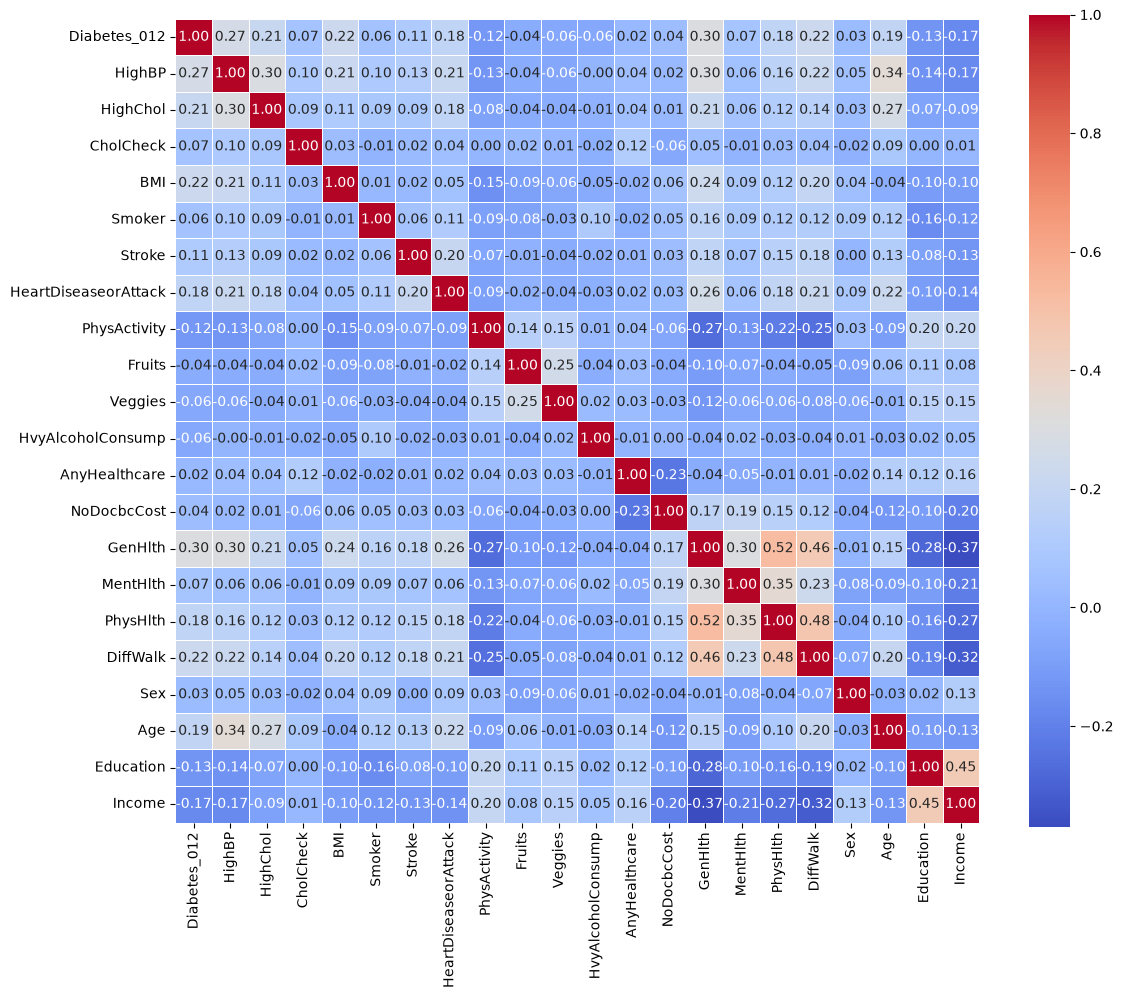

In [26]:
plt.figure(figsize = (12, 10))

sns.heatmap(data.corr(), annot=True, fmt = '.2f', annot_kws = {'size': 10}, linewidths = 0.4, cmap = 'coolwarm', square = True)

plt.tight_layout()
plt.show()

# the correlations between the feature is good

In [27]:
data['CholCheck'].value_counts()

CholCheck
1.0    244210
0.0      9470
Name: count, dtype: int64

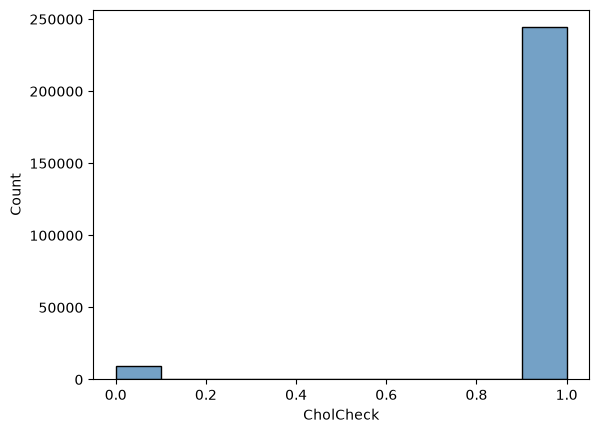

In [28]:
sns.histplot(data = data['CholCheck'], bins = 10, color = 'steelblue')
plt.show()

In [29]:
data['AnyHealthcare'].value_counts()

AnyHealthcare
1.0    241263
0.0     12417
Name: count, dtype: int64

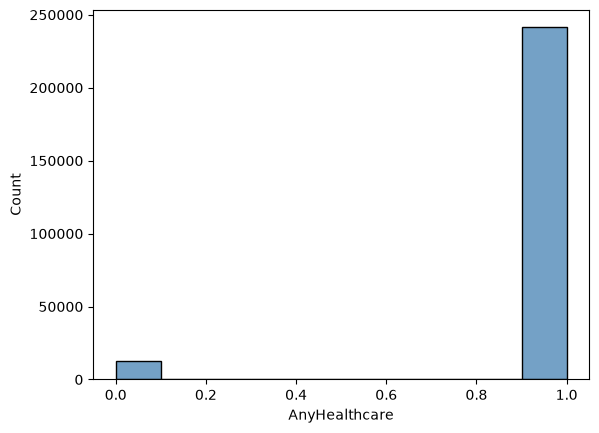

In [30]:
sns.histplot(data = data['AnyHealthcare'], fill = True, color = 'steelblue', bins = 10)
plt.show()

In [31]:
data['DiffWalk'].value_counts()

DiffWalk
0.0    211005
1.0     42675
Name: count, dtype: int64

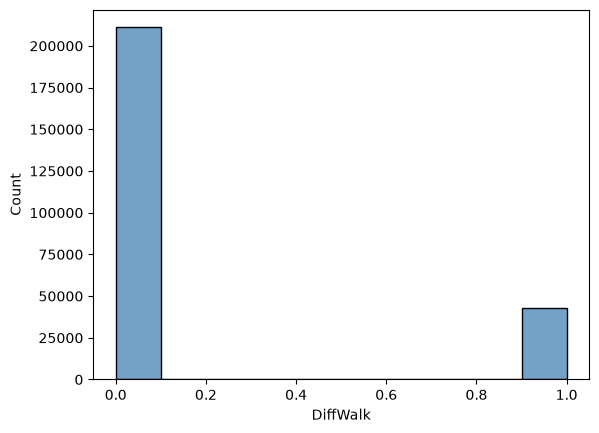

In [32]:
sns.histplot(data = data['DiffWalk'], bins = 10, color = 'steelblue')
plt.show()

In [33]:
data['Fruits'].value_counts()

Fruits
1.0    160898
0.0     92782
Name: count, dtype: int64

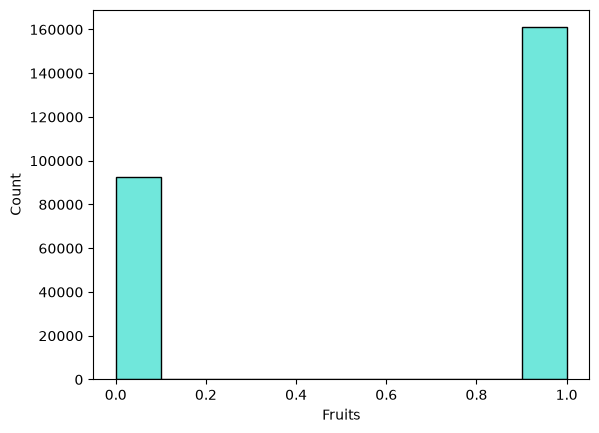

In [34]:
sns.histplot(data = data['Fruits'], bins = 10, color = 'turquoise')
plt.show()

In [35]:
data['HeartDiseaseorAttack'].value_counts()

HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

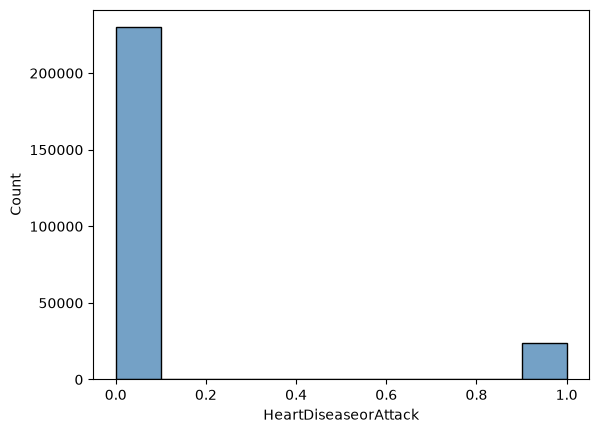

In [36]:
sns.histplot(data = data['HeartDiseaseorAttack'], bins = 10, color = 'steelblue')
plt.show()

In [37]:
data['HighBP'].value_counts()

HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64

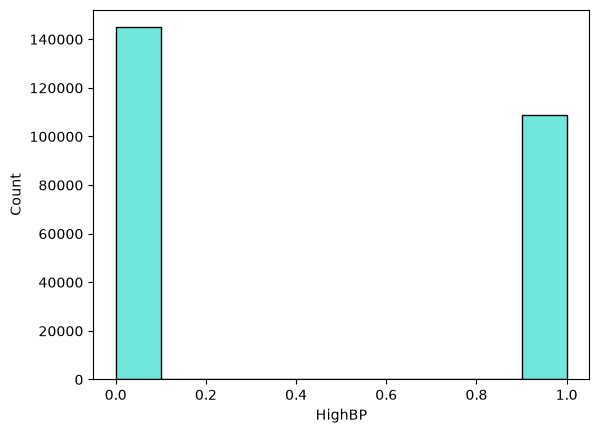

In [38]:
sns.histplot(data = data['HighBP'], bins = 10, color = 'turquoise')
plt.show()

In [39]:
data['HighChol'].value_counts()

HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64

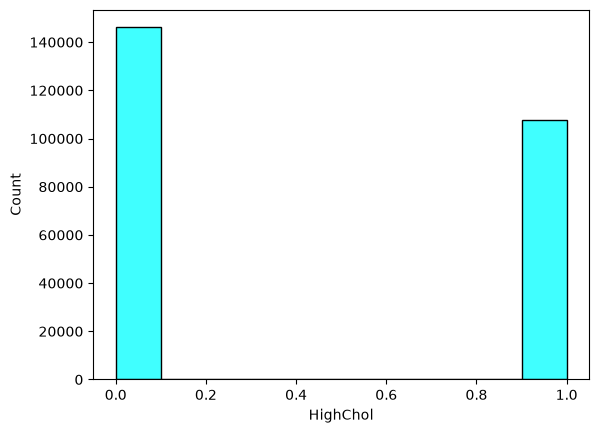

In [40]:
sns.histplot(data = data['HighChol'], bins = 10, color = 'aqua')
plt.show()

In [41]:
data['HvyAlcoholConsump'].value_counts()

HvyAlcoholConsump
0.0    239424
1.0     14256
Name: count, dtype: int64

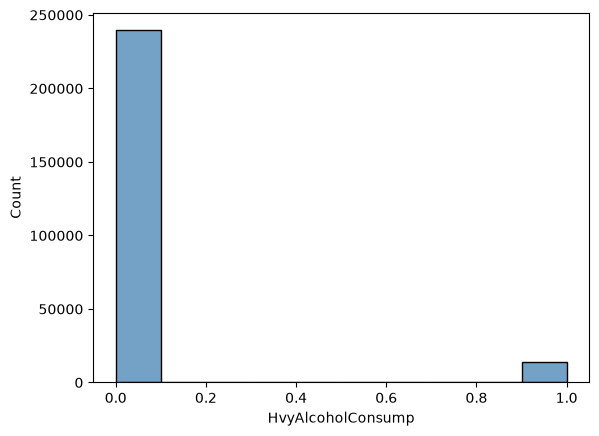

In [42]:
sns.histplot(data = data['HvyAlcoholConsump'], bins = 10, color = 'steelblue')
plt.show()

In [43]:
data['NoDocbcCost'].value_counts()

NoDocbcCost
0.0    232326
1.0     21354
Name: count, dtype: int64

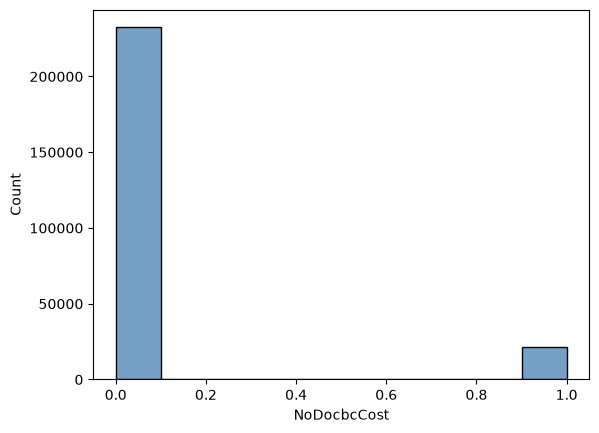

In [44]:
sns.histplot(data = data['NoDocbcCost'], bins = 10, color = 'steelblue')
plt.show()

In [45]:
data['PhysActivity'].value_counts()

PhysActivity
1.0    191920
0.0     61760
Name: count, dtype: int64

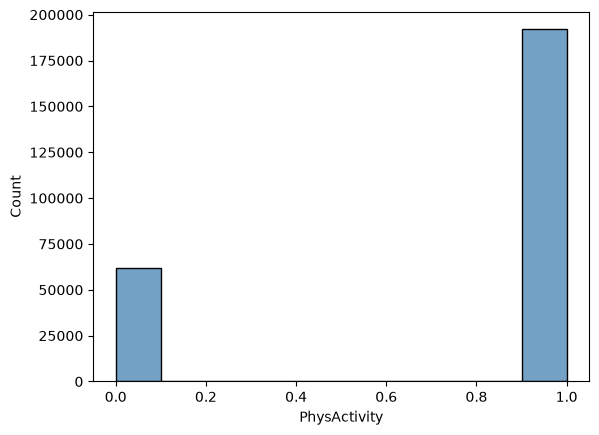

In [46]:
sns.histplot(data = data['PhysActivity'], bins = 10, color = 'SteelBlue')
plt.show()

In [47]:
data['Smoker'].value_counts()

Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64

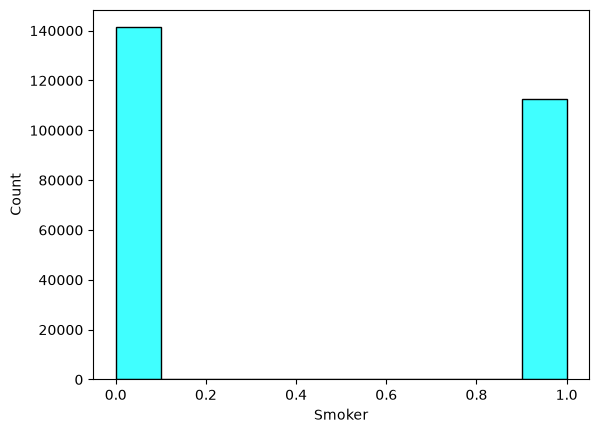

In [48]:
sns.histplot(data = data['Smoker'], bins = 10, color = 'aqua')
plt.show()

In [49]:
data['Stroke'].value_counts()

Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64

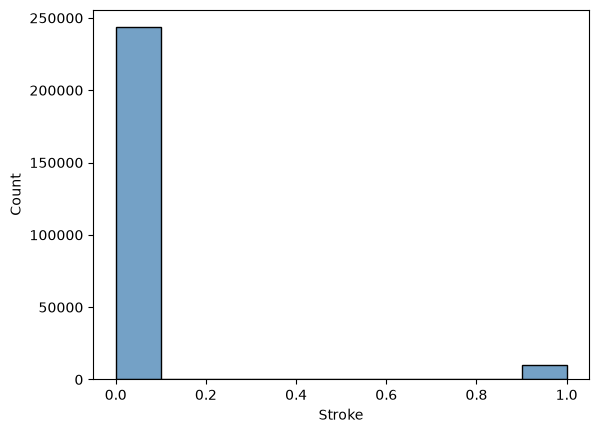

In [50]:
sns.histplot(data = data['Stroke'], bins = 10, color = 'steelblue')
plt.show()

In [51]:
data['Veggies'].value_counts()

Veggies
1.0    205841
0.0     47839
Name: count, dtype: int64

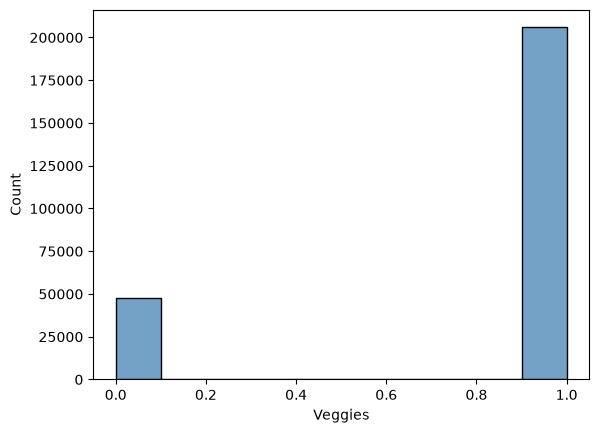

In [52]:
sns.histplot(data = data['Veggies'], bins = 10, color = 'steelblue')
plt.show()

In [53]:
data['Sex'].value_counts()

Sex
0.0    141974
1.0    111706
Name: count, dtype: int64

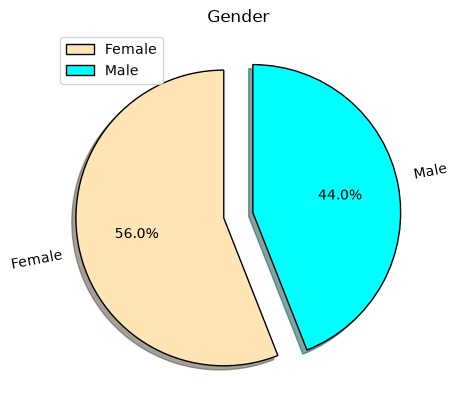

In [54]:
count_data = data['Sex'].value_counts()
colors = ['moccasin', 'cyan']
explode = [0.1, 0.1]
labels = ['Female', 'Male']

plt.pie(x = count_data, labels = labels, explode = explode, colors = colors, shadow = True, wedgeprops = {'edgecolor':'k'}, startangle = 90, rotatelabels = True, autopct = '%.1f%%')

plt.title('Gender')
plt.legend()
plt.show()


In [55]:
data['Age'].value_counts()

Age
9.0     33244
10.0    32194
8.0     30832
7.0     26314
11.0    23533
6.0     19819
13.0    17363
5.0     16157
12.0    15980
4.0     13823
3.0     11123
2.0      7598
1.0      5700
Name: count, dtype: int64

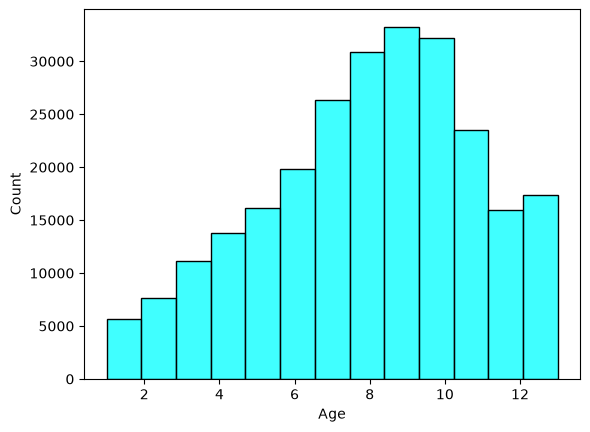

In [56]:
sns.histplot(data = data['Age'], bins = 13, color = 'aqua')
plt.show()

In [57]:
data['BMI'].value_counts()

BMI
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
96.0        1
91.0        1
86.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64

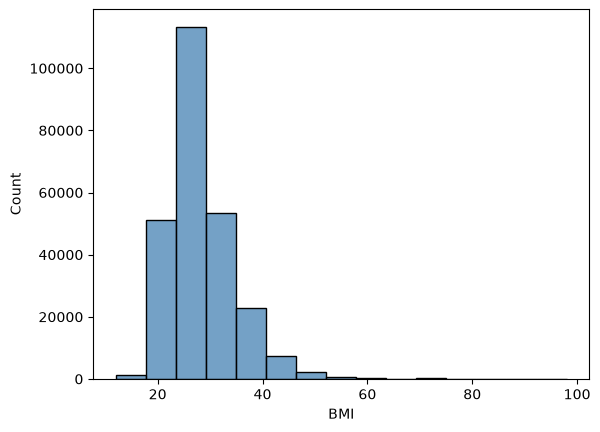

In [58]:
sns.histplot(data = data['BMI'], bins = 15, color = 'steelblue')
plt.show()

In [59]:
data['Education'].value_counts()

Education
6.0    107325
5.0     69910
4.0     62750
3.0      9478
2.0      4043
1.0       174
Name: count, dtype: int64

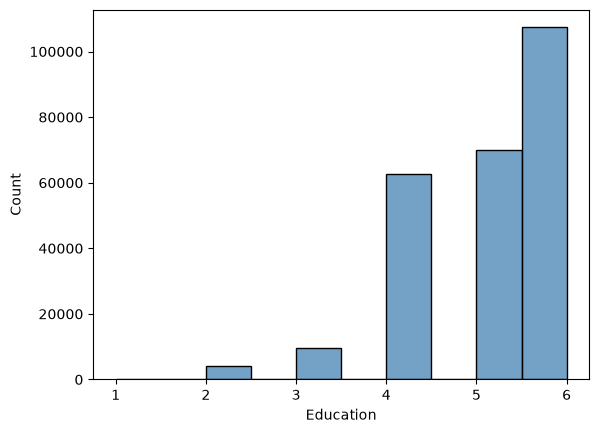

In [60]:
sns.histplot(data = data['Education'], bins = 10, color = 'steelblue')
plt.show()

In [61]:
data['GenHlth'].value_counts()

GenHlth
2.0    89084
3.0    75646
1.0    45299
4.0    31570
5.0    12081
Name: count, dtype: int64

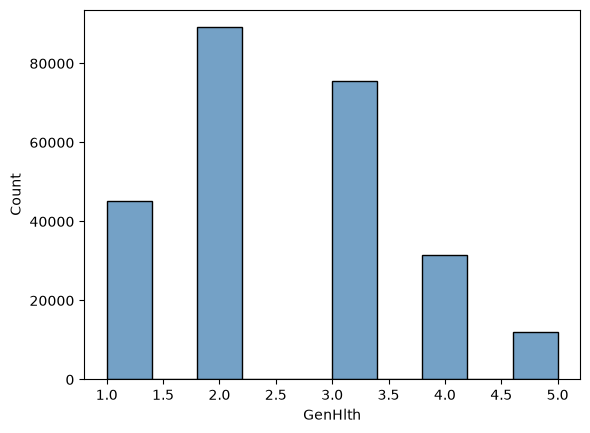

In [62]:
sns.histplot(data = data['GenHlth'], bins = 10, color = 'steelblue')
plt.show()

In [63]:
data['Income'].value_counts()

Income
8.0    90385
7.0    43219
6.0    36470
5.0    25883
4.0    20135
3.0    15994
2.0    11783
1.0     9811
Name: count, dtype: int64

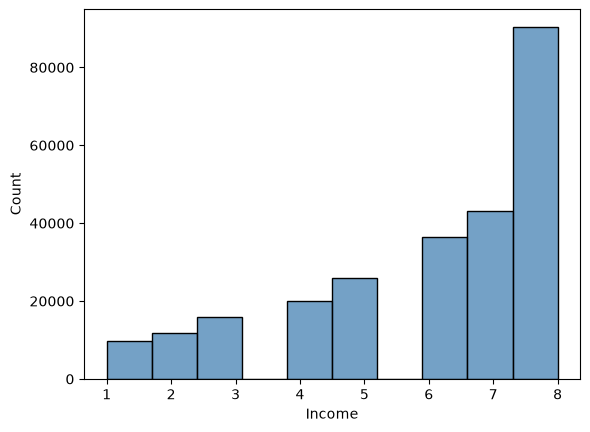

In [64]:
sns.histplot(data = data['Income'], bins = 10, color = 'steelblue')
plt.show()

In [65]:
data['PhysHlth'].value_counts()

PhysHlth
0.0     160052
30.0     19400
2.0      14764
1.0      11388
3.0       8495
5.0       7622
10.0      5595
15.0      4916
4.0       4542
7.0       4538
20.0      3273
14.0      2587
25.0      1336
6.0       1330
8.0        809
21.0       663
12.0       578
28.0       522
29.0       215
9.0        179
18.0       152
16.0       112
27.0        99
17.0        96
24.0        72
22.0        70
26.0        69
13.0        68
11.0        60
23.0        56
19.0        22
Name: count, dtype: int64

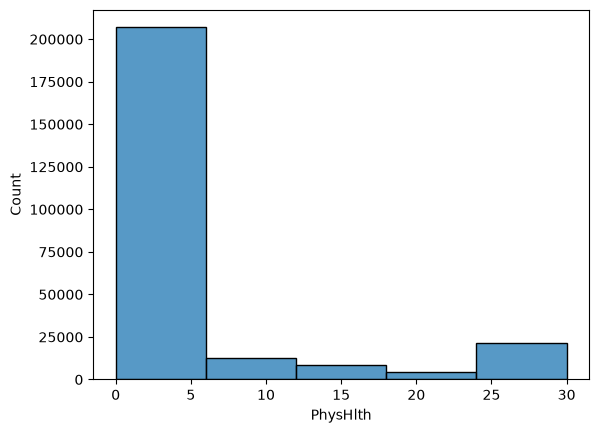

In [66]:
sns.histplot(data= data['PhysHlth'], bins = 5)
plt.show()